# CIFAR-10 Classification


This notebook implements CIFAR-10 cclassification using pytorch

## Load and preprocess data
Here we import pytorch, augment the data and convert into tensors

In [11]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

#Transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#Load the dataset
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)


In [2]:
## Building CNN

import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN()


## Training the Model

In [3]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


In [4]:
train_loss_list, train_acc_list = [], []

for epoch in range(8):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images, labels

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    train_loss_list.append(epoch_loss)
    train_acc_list.append(epoch_acc)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch 1, Loss: 1.7812, Accuracy: 35.14%
Epoch 2, Loss: 1.4281, Accuracy: 47.56%
Epoch 3, Loss: 1.2741, Accuracy: 53.55%
Epoch 4, Loss: 1.1738, Accuracy: 57.92%
Epoch 5, Loss: 1.0994, Accuracy: 61.24%
Epoch 6, Loss: 1.0400, Accuracy: 63.37%
Epoch 7, Loss: 0.9937, Accuracy: 65.11%
Epoch 8, Loss: 0.9599, Accuracy: 66.20%


## Evaluate Model

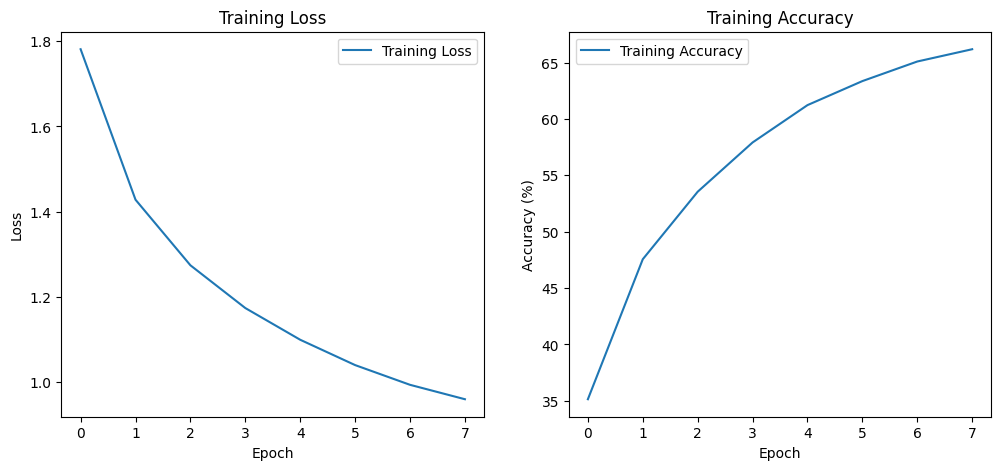

In [5]:
import matplotlib.pyplot as plt

# Plot accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

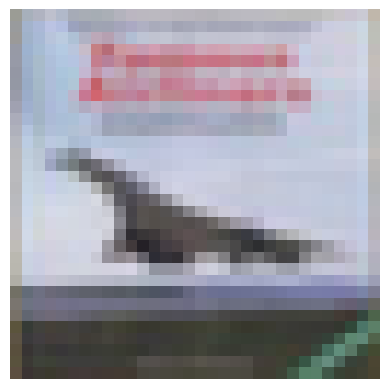

Predicted: ship, Actual: airplane


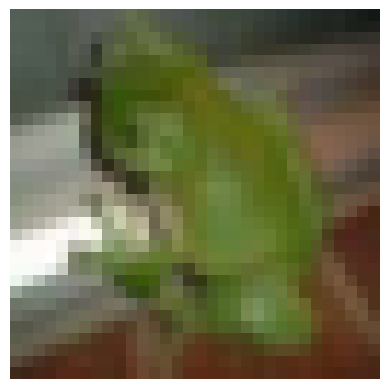

Predicted: bird, Actual: frog


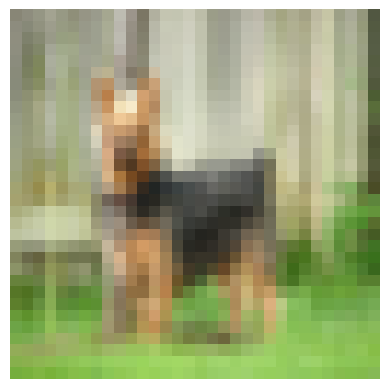

Predicted: deer, Actual: dog


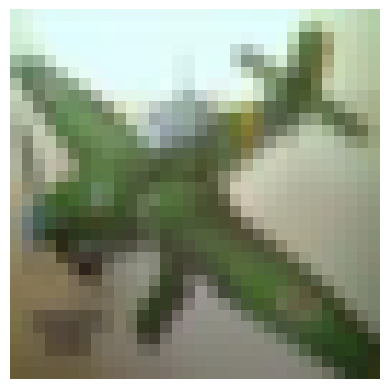

Predicted: bird, Actual: airplane


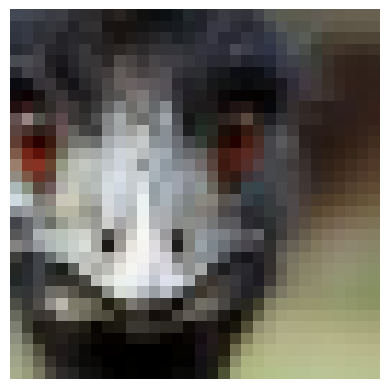

Predicted: cat, Actual: bird


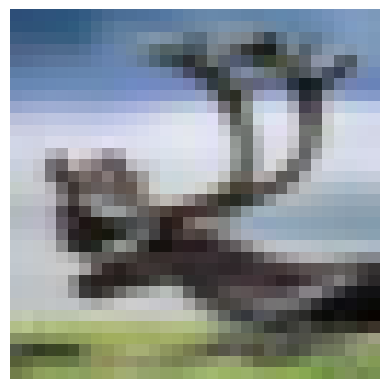

Predicted: airplane, Actual: deer


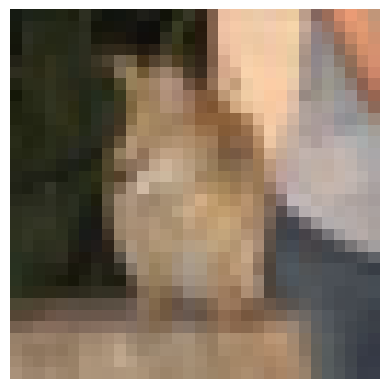

Predicted: dog, Actual: cat


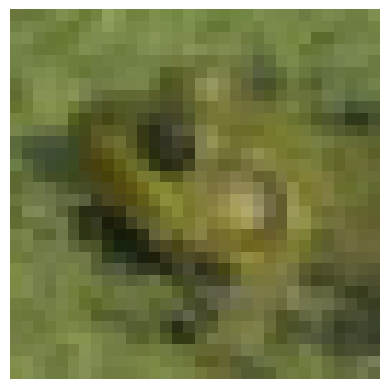

Predicted: bird, Actual: frog


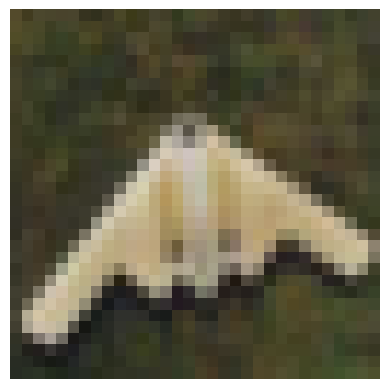

Predicted: bird, Actual: airplane


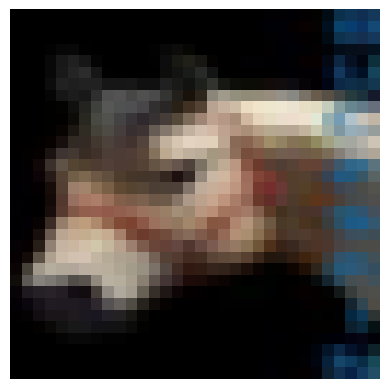

Predicted: dog, Actual: horse


In [8]:
import numpy as np

model.eval()
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images, labels
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for img, pred, label in zip(images, preds, labels):
            if pred != label and len(misclassified) < 10:
                misclassified.append((img.cpu(), pred.cpu(), label.cpu()))

# Show misclassified images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()
classes = train_dataset.classes
for img, pred, label in misclassified:
    imshow(img)
    print(f"Predicted: {classes[pred]}, Actual: {classes[label]}")
